In [19]:
# ============================================================
# 1. INSTALL + PARAMETERS
# ============================================================
# Colab already ships torch / transformers / sentence-transformers / scikit-learn /
# pandas / seaborn / statsmodels / datasets / aiohttp, so we only add what is missing.
# NOTE: `duckduckgo-search` is the OLD name of the package; the code imports `ddgs`.
!pip install -q ddgs trafilatura python-dotenv
!apt-get install -y -qq zstd pciutils lshw > /dev/null 2>&1

import os, sys, json, time, random, asyncio, re, string, shutil, subprocess, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ---------------------------- PARAMETERS ----------------------------
N_SAMPLES         = 400     # Use 400 for the real run.
SEED              = 42
MODEL_NAME        = "llama3.2:3b"
DATASET_SPLIT     = "validation"
SEARCH_DELAY      = (1.5, 3.5)   # polite random pause (s) before every NEW web search
LLM_TIMEOUT       = 120          # s per generation call (the very first call also loads the model)
RETRIEVAL_TIMEOUT = 45           # s hard ceiling for search + page fetching per question
MIN_PER_CLASS     = 10           # need at least this many correct AND incorrect answers to train
GATE_CAP          = 0.5          # score ceiling applied when NLI sees a strong contradiction
GATE_MIN_GAIN     = 0.005        # gate is only adopted if it improves cross-validated AUC by this much

FEATURES = [
    "evidence_max", "evidence_mean", "consistency",
    "p_contradiction_max", "p_contradiction_mean",
    "p_entailment_max", "p_entailment_mean",
    "refusal_fraction", "verification_failed",
    "retrieval_relevance", "answer_length_words",
]

# ------------------------------ PATHS -------------------------------
from google.colab import drive
drive.mount("/content/drive")
BASE_DIR          = "/content/drive/MyDrive/LLM_Reliability"
os.makedirs(BASE_DIR, exist_ok=True)
CHECKPOINT_FILE   = os.path.join(BASE_DIR, "engine_checkpoint.jsonl")
CACHE_FILE        = os.path.join(BASE_DIR, "search_cache.json")
MODEL_EXPORT_FILE = os.path.join(BASE_DIR, "scoring_model.json")

random.seed(SEED)
np.random.seed(SEED)


class StopCell(Exception):
    """Raised to stop a cell with a friendly message instead of a scary traceback."""
    def _render_traceback_(self):
        return ["⏹  " + str(self.args[0])]


print("Setup done.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done.


In [20]:
# ============================================================
# 2. LOCATE YOUR `core` PACKAGE (and fix one library-version incompatibility)
# ============================================================
REQUIRED = ["config.py", "llm_client.py", "refusal.py", "retriever.py", "scorer.py"]
CORE_DIR = "/content/core"
candidates = ["/content/core", "/content", "/content/LLM_Reliability/core", "/content/LLM_Reliability"]

def _has_all(d):
    return all(os.path.isfile(os.path.join(d, f)) for f in REQUIRED)

src_dir = next((d for d in candidates if _has_all(d)), None)
if src_dir is None:
    print("Could not find all of", REQUIRED)
    print("Contents of /content:", sorted(os.listdir("/content")))
    raise FileNotFoundError("Upload the five .py files to /content/core/ (or directly to /content/) and re-run this cell.")

if src_dir != CORE_DIR:                      # files were uploaded flat -> rebuild the package
    os.makedirs(CORE_DIR, exist_ok=True)
    for f in REQUIRED:
        shutil.copy(os.path.join(src_dir, f), os.path.join(CORE_DIR, f))
    print(f"Copied core files from {src_dir} -> {CORE_DIR}")
open(os.path.join(CORE_DIR, "__init__.py"), "a").close()   # make sure it is a package

# scorer.py builds the NLI model with pipeline(..., framework="pt"). transformers 5.x removed the
# `framework` argument (it is then silently forwarded to the tokenizer and breaks inference).
# Dropping it is safe on every version, because PyTorch is auto-selected.
scorer_path = os.path.join(CORE_DIR, "scorer.py")
code = open(scorer_path).read()
patched = re.sub(r""",\s*framework\s*=\s*["']pt["']""", "", code)
if patched != code:
    open(scorer_path, "w").write(patched)
    print("Patched scorer.py: removed framework='pt' from the NLI pipeline (this Colab copy only).")

if "/content" not in sys.path:
    sys.path.insert(0, "/content")
if "core" in sys.modules:
    print("⚠ `core` was already imported in this session -> use Runtime > Restart session, then run again.")
print("core package ready at", CORE_DIR)


⚠ `core` was already imported in this session -> use Runtime > Restart session, then run again.
core package ready at /content/core


In [21]:
# ============================================================
# 3. START OLLAMA AND CHECK THAT IT REALLY ANSWERS
# ============================================================
import requests

OLLAMA_BASE = "http://127.0.0.1:11434"      # 127.0.0.1, not "localhost" (avoids IPv6 lookup problems)

def ollama_is_up():
    try:
        return requests.get(f"{OLLAMA_BASE}/api/tags", timeout=2).status_code == 200
    except Exception:
        return False

print(subprocess.run("nvidia-smi -L", shell=True, capture_output=True, text=True).stdout.strip()
      or "⚠ No GPU detected (Runtime > Change runtime type > T4 GPU). It will still run, just slower.")

ollama_path = shutil.which("ollama") or "/usr/local/bin/ollama"
if not os.path.exists(ollama_path):
    print("Installing Ollama ...")
    r = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh", shell=True, capture_output=True, text=True)
    print((r.stdout + r.stderr)[-1500:])
    ollama_path = shutil.which("ollama") or "/usr/local/bin/ollama"
    if not os.path.exists(ollama_path):
        raise RuntimeError("Ollama installation failed - read the output above.")

# NUM_PARALLEL=3 lets the 3 concurrent generations per question run in parallel instead of queueing
ollama_env = {**os.environ, "OLLAMA_HOST": "127.0.0.1:11434",
              "OLLAMA_NUM_PARALLEL": "3", "OLLAMA_KEEP_ALIVE": "4h"}

if not ollama_is_up():
    server_log = open("/content/ollama_server.log", "w")
    ollama_proc = subprocess.Popen([ollama_path, "serve"], env=ollama_env,
                                   stdout=server_log, stderr=subprocess.STDOUT)
    for _ in range(60):
        if ollama_is_up():
            break
        time.sleep(1)
    else:
        print(open("/content/ollama_server.log").read()[-3000:])
        raise RuntimeError("Ollama server did not start within 60 s (log printed above).")
print("Ollama server is up.")

print(f"Pulling {MODEL_NAME} ...")
subprocess.run([ollama_path, "pull", MODEL_NAME], env=ollama_env, check=True)

# Warm-up: loads the model into memory so the first real questions don't time out
t0 = time.time()
r = requests.post(f"{OLLAMA_BASE}/api/generate",
                  json={"model": MODEL_NAME, "prompt": "What is the capital of France?",
                        "stream": False, "options": {"num_predict": 20}}, timeout=300)
r.raise_for_status()
print(f"Warm-up reply: {r.json()['response'].strip()[:80]!r}  ({time.time() - t0:.1f}s)")
print(subprocess.run([ollama_path, "ps"], env=ollama_env, capture_output=True, text=True).stdout)


GPU 0: Tesla T4 (UUID: GPU-b9333d32-a867-11ac-e728-2ba706bc70f1)
Ollama server is up.
Pulling llama3.2:3b ...
Warm-up reply: 'The capital of France is Paris.'  (6.7s)
NAME           ID              SIZE      PROCESSOR    CONTEXT    UNTIL            
llama3.2:3b    a80c4f17acd5    3.6 GB    100% GPU     4096       4 hours from now    



In [22]:
# ============================================================
# 4. IMPORT YOUR CORE MODULES
# ============================================================
# core/config.py reads these when it is imported, so set them BEFORE the import.
os.environ["OLLAMA_URL"]   = f"{OLLAMA_BASE}/api/generate"
os.environ["MODEL_NAME"]   = MODEL_NAME
os.environ["LLM_TIMEOUT"]  = str(LLM_TIMEOUT)
os.environ["RETRIEVAL_TIMEOUT"] = str(RETRIEVAL_TIMEOUT)

print("Importing core (first run downloads the embedding + NLI models, ~1.5 GB) ...")
import core.config as config
# ...and set them explicitly too, in case `core` was imported earlier in this session
config.settings.OLLAMA_URL        = f"{OLLAMA_BASE}/api/generate"
config.settings.MODEL_NAME        = MODEL_NAME
config.settings.LLM_TIMEOUT       = float(LLM_TIMEOUT)
config.settings.RETRIEVAL_TIMEOUT = float(RETRIEVAL_TIMEOUT)

import aiohttp
import torch
import core.scorer as scorer_module
from core.llm_client import generate_response, is_generation_failure
from core.refusal import is_refusal
from core.scorer import get_embedding, cosine_similarity, self_consistency, nli_analyzer
from core.retriever import get_search_results, fetch_and_extract, chunk_text, rank_passages

# transformers 4.x builds the pipeline on CPU by default -> move the NLI model to the GPU
if torch.cuda.is_available() and nli_analyzer.model.device.type != "cuda":
    nli_analyzer.model.to("cuda")
    nli_analyzer.device = torch.device("cuda:0")
print("NLI model on:", nli_analyzer.model.device, "| embedding model on:", scorer_module.embedding_model.device)

# Sanity check: proves the NLI call shape and label names BEFORE we spend an hour on it
_probe = nli_analyzer([{"text": "The Eiffel Tower is in Paris.", "text_pair": "The Eiffel Tower is in France."}],
                      truncation=True, top_k=None)
print("NLI probe:", _probe)
_labels = {d["label"].upper() for d in _probe[0]}
assert _labels & {"CONTRADICTION", "LABEL_0"} and _labels & {"ENTAILMENT", "LABEL_2"}, f"Unexpected NLI labels: {_labels}"
print("✅ core modules imported and NLI works.")


Importing core (first run downloads the embedding + NLI models, ~1.5 GB) ...
NLI model on: cuda:0 | embedding model on: cuda:0
NLI probe: [[{'label': 'ENTAILMENT', 'score': 0.9607858657836914}, {'label': 'NEUTRAL', 'score': 0.03482615575194359}, {'label': 'CONTRADICTION', 'score': 0.004387992434203625}]]
✅ core modules imported and NLI works.


In [23]:
# ============================================================
# 5. LOAD TRIVIAQA + LABELLING FUNCTION
# ============================================================
from datasets import load_dataset

trivia_qa = None
# `datasets` 4.x no longer runs dataset scripts, so use the parquet copy under its full Hub name first
for _name in ["mandarjoshi/trivia_qa", "trivia_qa"]:
    try:
        trivia_qa = load_dataset(_name, "rc.nocontext", split=DATASET_SPLIT)
        print(f"Loaded {_name}: {len(trivia_qa)} rows")
        break
    except Exception as e:
        print(f"  could not load {_name}: {type(e).__name__}: {str(e)[:200]}")
if trivia_qa is None:
    raise RuntimeError("TriviaQA could not be loaded - check the messages above (internet / HF Hub access).")

trivia_qa = trivia_qa.shuffle(seed=SEED).select(range(min(N_SAMPLES, len(trivia_qa))))
questions = [{"question_id": ex["question_id"], "question": ex["question"],
              "aliases": list(ex["answer"]["aliases"])} for ex in trivia_qa]
print(f"Using {len(questions)} questions.")

_PUNCT = str.maketrans("", "", string.punctuation)

def normalize_text(text: str) -> str:
    """Official TriviaQA normalisation: lowercase -> drop punctuation -> drop articles -> squeeze spaces."""
    text = text.lower().translate(_PUNCT)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def evaluate_correctness(model_output: str, gold_aliases: list) -> int:
    """1 if ANY gold alias appears in the answer as whole words, else 0.
    Whole-word matching stops 'art' matching 'party'; empty aliases (e.g. 'the') are skipped,
    otherwise '' would be a substring of everything and every answer would count as correct."""
    padded_output = f" {normalize_text(model_output)} "
    for alias in gold_aliases:
        a = normalize_text(alias)
        if a and f" {a} " in padded_output:
            return 1
    return 0

# quick self-tests of the labeller
assert evaluate_correctness("The capital is Paris.", ["Paris"]) == 1
assert evaluate_correctness("A Parisian style", ["Paris"]) == 0
assert evaluate_correctness("Anything at all", ["the", ""]) == 0
print("Labeller self-tests passed.")


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Loaded mandarjoshi/trivia_qa: 17944 rows
Using 400 questions.
Labeller self-tests passed.


In [24]:
# ============================================================
# 6. CACHED WEB RETRIEVAL + NLI FEATURES
# ============================================================
# --- search cache (lives on Drive so re-runs never search twice) ---
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        search_cache = json.load(f)
else:
    search_cache = {}
_new_since_save = 0

def save_cache():
    with open(CACHE_FILE, "w") as f:
        json.dump(search_cache, f)

async def polite_search(query: str, max_results: int = 5):
    """Cached search with random jitter so DuckDuckGo does not rate-limit us."""
    global _new_since_save
    if query in search_cache:
        return search_cache[query]
    await asyncio.sleep(random.uniform(*SEARCH_DELAY))
    results = await get_search_results(query, max_results=max_results)
    if results:                        # never cache a failed/empty search, or it can never be retried
        search_cache[query] = results
        _new_since_save += 1
        if _new_since_save >= 10:
            save_cache()
            _new_since_save = 0
    return results

async def gather_passages_robust(query: str):
    search_results = await polite_search(query)
    if not search_results:
        return []
    async with aiohttp.ClientSession() as session:
        texts = await asyncio.gather(*[fetch_and_extract(session, r["url"]) for r in search_results],
                                     return_exceptions=True)
    passages = []
    for res, txt in zip(search_results, texts):
        full_text = txt if isinstance(txt, str) and txt else res["text"]
        for chunk in chunk_text(full_text):
            passages.append({"url": res["url"], "text": chunk})
    return passages

# --- NLI features ---
def _probs_from_result(res):
    """One (premise, hypothesis) result -> (p_contradiction, p_neutral, p_entailment)."""
    if isinstance(res, dict):
        res = [res]
    probs = {d["label"].upper(): float(d["score"]) for d in res}
    return (probs.get("CONTRADICTION", probs.get("LABEL_0", 0.0)),
            probs.get("NEUTRAL",       probs.get("LABEL_1", 0.0)),
            probs.get("ENTAILMENT",    probs.get("LABEL_2", 0.0)))

def extract_nli_features(response: str, evidence_passages: list) -> dict:
    """Real class probabilities (top_k=None) instead of 'top label x magic constant'.
    Also returns h_penalty_prod = what the CURRENT production code would compute, used only
    to score the hard-coded baseline fairly. Exceptions are NOT swallowed here on purpose."""
    if not evidence_passages:
        return {"p_contradiction_max": 0.0, "p_contradiction_mean": 0.0,
                "p_entailment_max": 0.0, "p_entailment_mean": 0.0, "h_penalty_prod": 1.0}
    hypothesis = response[:200] or "no answer"
    inputs = [{"text": p["text"][:400], "text_pair": hypothesis} for p in evidence_passages]
    results = nli_analyzer(inputs, truncation=True, top_k=None, batch_size=8)

    contra, entail, penalties = [], [], []
    for res in results:
        c, n, e = _probs_from_result(res)
        contra.append(c); entail.append(e)
        top = max((("C", c), ("N", n), ("E", e)), key=lambda t: t[1])[0]
        penalties.append(0.9 * c if top == "C" else 0.2 * n if top == "N" else 0.0)
    return {"p_contradiction_max": float(np.max(contra)), "p_contradiction_mean": float(np.mean(contra)),
            "p_entailment_max": float(np.max(entail)),    "p_entailment_mean": float(np.mean(entail)),
            "h_penalty_prod": float(np.mean(penalties))}

print("Retrieval + NLI helpers ready. Cached searches so far:", len(search_cache))


Retrieval + NLI helpers ready. Cached searches so far: 57


In [25]:
# ============================================================
# 7. RUN THE ENGINE OVER THE QUESTIONS (resumable)
# ============================================================
def _json_default(o):
    if isinstance(o, (np.integer,)):  return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)):    return bool(o)
    raise TypeError(f"not JSON serialisable: {type(o)}")

# --- resume from checkpoint (tolerate a half-written last line after a crash) ---
processed_data, processed_ids = [], set()
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        for line in f:
            try:
                item = json.loads(line)
            except json.JSONDecodeError:
                continue
            processed_data.append(item)
            processed_ids.add(item["question_id"])
    print(f"Resuming: {len(processed_ids)} questions already in the checkpoint.")

run_stats = collections.Counter()
_first_error = {}

def _note(kind: str, msg: str):
    """Count a problem and print the FIRST message of each kind, so failures are never silent."""
    run_stats[kind] += 1
    if kind not in _first_error:
        _first_error[kind] = msg
        print(f"\n⚠ first '{kind}': {msg[:400]}")

async def process_question(item: dict):
    question, gold = item["question"], item["aliases"]

    # 1) three samples, concurrently
    raw = [r[0] for r in await asyncio.gather(*[generate_response(question) for _ in range(3)])]
    outputs = [o for o in raw if not is_generation_failure(o)]
    if not outputs:
        _note("generation_failed", raw[0])
        return None

    refusals = [is_refusal(o) for o in outputs]
    refused_all = all(refusals)
    non_refusing = [o for o, r in zip(outputs, refusals) if not r]
    main_output = non_refusing[0] if non_refusing else outputs[0]      # same rule as production
    consistency = self_consistency(outputs) if len(outputs) >= 2 else 1.0

    record = {"question_id": item["question_id"], "question": question, "main_output": main_output,
              "gold_aliases": gold, "refused_all": refused_all,
              "is_correct": None if refused_all else evaluate_correctness(main_output, gold),
              "consistency": consistency, "refusal_fraction": sum(refusals) / len(outputs),
              "answer_length_words": len(main_output.split())}

    if refused_all:                        # nothing to verify -> skip the web (saves search quota)
        record.update({f: None for f in FEATURES if f not in record})
        record["baseline_score"] = None
        return record

    # 2) evidence
    try:
        candidates = await asyncio.wait_for(gather_passages_robust(question), timeout=RETRIEVAL_TIMEOUT)
    except asyncio.TimeoutError:
        _note("retrieval_timeout", question)
        candidates = []
    evidence = rank_passages(candidates, main_output, top_k=3)
    verification_failed = int(len(evidence) == 0)
    if verification_failed:
        run_stats["no_evidence"] += 1
        evidence_max = evidence_mean = retrieval_relevance = 0.0
    else:
        scores = [p["score"] for p in evidence]
        evidence_max, evidence_mean = max(scores), sum(scores) / len(scores)
        retrieval_relevance = cosine_similarity(get_embedding(question), get_embedding(evidence[0]["text"]))

    # 3) NLI
    try:
        nli = extract_nli_features(main_output, evidence)
    except Exception as e:
        _note("nli_error", f"{type(e).__name__}: {e}")
        return None

    # 4) the CURRENT hard-coded production formula (no reference), kept as the baseline to beat
    baseline = 0.60 * evidence_max + 0.40 * consistency - 0.30 * nli["h_penalty_prod"]
    record.update({"evidence_max": evidence_max, "evidence_mean": evidence_mean,
                   "p_contradiction_max": nli["p_contradiction_max"], "p_contradiction_mean": nli["p_contradiction_mean"],
                   "p_entailment_max": nli["p_entailment_max"], "p_entailment_mean": nli["p_entailment_mean"],
                   "verification_failed": verification_failed, "retrieval_relevance": retrieval_relevance,
                   "baseline_score": float(min(1.0, max(0.0, baseline)))})
    return record

async def main_loop():
    todo = [q for q in questions if q["question_id"] not in processed_ids]
    print(f"{len(todo)} questions to process ({len(processed_ids)} already done).")
    if not todo:
        return
    try:
        with open(CHECKPOINT_FILE, "a") as f:
            pbar = tqdm(todo, desc="Questions")
            for item in pbar:
                record = await process_question(item)
                if record is not None:
                    f.write(json.dumps(record, default=_json_default) + "\n")
                    f.flush()
                    processed_data.append(record)
                    processed_ids.add(record["question_id"])
                    run_stats["saved"] += 1
                pbar.set_postfix(dict(run_stats))
    finally:
        save_cache()

await main_loop()          # Colab supports top-level await, so no asyncio.run / nest_asyncio needed
print("\nRun summary:", dict(run_stats))


Resuming: 60 questions already in the checkpoint.
340 questions to process (60 already done).


Questions:   0%|          | 0/340 [00:00<?, ?it/s]

DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.
DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.


DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.
DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.
DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > No route to host (os error 113)')
DDGS attempt 2 failed: No results found.
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: No results found.
DDGS attempt 2 failed: ConnectError: ConnectError('error sending request for url (http

DDGS attempt 1 failed: No results found.
DDGS attempt 1 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS attempt 2 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS attempt 2 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 2 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: error sending request for url (https://html.duc

...

DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 2 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: ConnectError: ConnectError('error sending reque

ERROR:trafilatura.utils:parsed tree length: 0, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 2 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 2 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: 

DDGS attempt 1 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS attempt 1 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS attempt 2 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')


DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 2 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: error sending request for url (https://html.duckduckgo.com/html/) > operation timed out
DDGS attempt 2 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS exhausted. Falling back to Wikipedia API.
DDGS attempt 1 failed: ConnectError: ConnectError('error sending request for url (https://www.startpage.com/) > client error (Connect) > tcp connect error > Connection refused (os error 111)')
DDGS attempt 1 failed: 

In [26]:
# ============================================================
# 8. BUILD THE TRAINING TABLE + LABEL SPOT-CHECK
# ============================================================
df = pd.DataFrame(processed_data)
if df.empty:
    raise StopCell(f"No records were produced. Counters: {dict(run_stats)}. "
                   "Read the '⚠ first ...' message printed by cell 7 and /content/ollama_server.log.")

total = len(df)
refused_count = int(df["refused_all"].astype(bool).sum())
print(f"Total processed: {total}")
print(f"Refused on all 3 samples: {refused_count} ({refused_count / total * 100:.1f}%)  <- reported, not trained on")

df_trainable = df[~df["refused_all"].astype(bool)].copy()
df_trainable = df_trainable.dropna(subset=FEATURES + ["is_correct"])
df_trainable["is_correct"] = df_trainable["is_correct"].astype(int)

n_pos = int(df_trainable["is_correct"].sum())
n_neg = len(df_trainable) - n_pos
print(f"Trainable rows: {len(df_trainable)}  (correct: {n_pos}, incorrect: {n_neg})")
print(f"No web evidence found for {int(df_trainable['verification_failed'].sum())} of them")

if len(df_trainable):
    print("\n--- FEATURE SANITY CHECK (an all-zero row here would mean a broken signal) ---")
    print(df_trainable[FEATURES].describe().T[["mean", "std", "min", "max"]].round(3))

    print("\n--- LABEL NOISE SPOT-CHECK (read these: are the labels right?) ---")
    for _, row in df_trainable.sample(min(15, len(df_trainable)), random_state=SEED).iterrows():
        print("✅ CORRECT" if row["is_correct"] else "❌ WRONG")
        print("Q:", row["question"])
        print("A:", row["main_output"][:150].replace("\n", " "), "...")
        print("Gold:", row["gold_aliases"][:3], "\n")

CAN_MODEL = n_pos >= MIN_PER_CLASS and n_neg >= MIN_PER_CLASS
if CAN_MODEL:
    print("✅ Enough labelled data - continue with the modelling cells.")
else:
    print(f"ℹ️ Smoke test complete: the pipeline works end-to-end. Training needs >= {MIN_PER_CLASS} correct and "
          f">= {MIN_PER_CLASS} incorrect answers (you have {n_pos}/{n_neg}). Set N_SAMPLES = 400 in cell 1 and "
          "re-run from cell 1 - finished questions are reloaded from the checkpoint. "
          "The modelling cells below will stop with a message until then.")


Total processed: 400
Refused on all 3 samples: 7 (1.8%)  <- reported, not trained on
Trainable rows: 393  (correct: 204, incorrect: 189)
No web evidence found for 77 of them

--- FEATURE SANITY CHECK (an all-zero row here would mean a broken signal) ---
                        mean     std    min     max
evidence_max           0.596   0.317  0.000   0.949
evidence_mean          0.561   0.301  0.000   0.921
consistency            0.866   0.128  0.315   1.000
p_contradiction_max    0.404   0.426  0.000   0.999
p_contradiction_mean   0.309   0.367  0.000   0.999
p_entailment_max       0.330   0.411  0.000   0.994
p_entailment_mean      0.233   0.329  0.000   0.992
refusal_fraction       0.095   0.195  0.000   0.667
verification_failed    0.196   0.397  0.000   1.000
retrieval_relevance    0.558   0.293 -0.068   0.978
answer_length_words   23.252  13.942  2.000  57.000

--- LABEL NOISE SPOT-CHECK (read these: are the labels right?) ---
✅ CORRECT
Q: On a motorway what is the speed limit for

train=314  test=79  (test accuracy of the raw LLM: 51.9%)

Baseline 0 (hard-coded formula)  test ROC-AUC: 0.833

--- Single-feature AUC (direction: + means higher = more likely correct) ---


,feature,direction,test AUC
1,evidence_mean,+,0.814
0,evidence_max,+,0.809
6,p_entailment_mean,+,0.786
5,p_entailment_max,+,0.786
2,consistency,+,0.781
4,p_contradiction_mean,-,0.713
7,refusal_fraction,-,0.687
3,p_contradiction_max,-,0.666
9,retrieval_relevance,+,0.626
10,answer_length_words,-,0.582


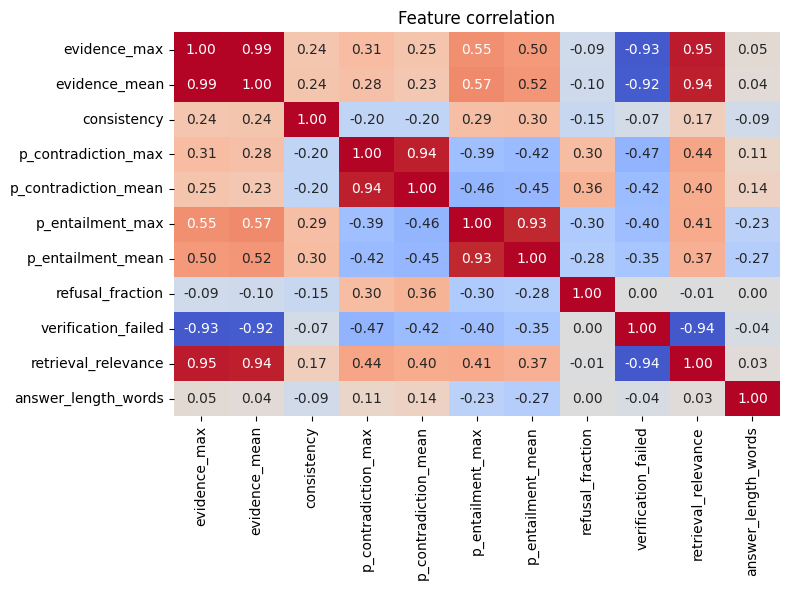

Variance inflation factors (>5 = strongly overlapping signals; don't over-read those coefficients):


,VIF
evidence_max,115.28
evidence_mean,99.34
consistency,1.25
p_contradiction_max,11.24
p_contradiction_mean,11.46
p_entailment_max,10.91
p_entailment_mean,8.92
refusal_fraction,1.24
verification_failed,13.35
retrieval_relevance,18.34



Logistic regression (C=10, 5-fold CV AUC=0.873)  test ROC-AUC: 0.936

Learned weights (these replace 0.6 / 0.4 / 0.3):


,coef (per std-dev)
evidence_max,2.623
retrieval_relevance,-1.938
verification_failed,1.776
evidence_mean,1.386
p_contradiction_mean,-0.867
refusal_fraction,-0.575
p_entailment_max,0.551
p_contradiction_max,0.292
p_entailment_mean,0.036
answer_length_words,0.029



Shallow GBM (comparison only)  test ROC-AUC: 0.940


In [27]:
# ============================================================
# 9. TRAIN / TEST SPLIT, BASELINES, LOGISTIC REGRESSION, GBM
# ============================================================
if not CAN_MODEL:
    raise StopCell("Not enough labelled data yet - see the message in cell 8.")

from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

X = df_trainable[FEATURES].to_numpy(dtype=float)
y = df_trainable["is_correct"].to_numpy(dtype=int)
row_ids = df_trainable.index.to_numpy()

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, row_ids, test_size=0.2, stratify=y, random_state=SEED)      # one row per question -> no leakage
print(f"train={len(y_train)}  test={len(y_test)}  (test accuracy of the raw LLM: {y_test.mean():.1%})")

# ---- Baseline 0: the current hard-coded formula ----
baseline_test = df_trainable.loc[id_test, "baseline_score"].to_numpy(dtype=float)
print(f"\nBaseline 0 (hard-coded formula)  test ROC-AUC: {roc_auc_score(y_test, baseline_test):.3f}")

# ---- Baseline 1: every feature on its own (direction chosen on TRAIN only) ----
single_rows, single_scores = [], {}
for i, name in enumerate(FEATURES):
    direction = 1.0 if roc_auc_score(y_train, X_train[:, i]) >= 0.5 else -1.0
    single_scores[name] = direction * X_test[:, i]
    single_rows.append({"feature": name, "direction": "+" if direction > 0 else "-",
                        "test AUC": roc_auc_score(y_test, single_scores[name])})
single_df = pd.DataFrame(single_rows).sort_values("test AUC", ascending=False)
print("\n--- Single-feature AUC (direction: + means higher = more likely correct) ---")
display(single_df.round(3))
best_single = single_df.iloc[0]["feature"]

# ---- Correlation + variance inflation (evidence and NLI both come from the same passages) ----
plt.figure(figsize=(8, 6))
sns.heatmap(df_trainable[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=False)
plt.title("Feature correlation"); plt.tight_layout(); plt.show()
try:
    import warnings
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    Xs = StandardScaler().fit_transform(X_train)
    keep = Xs.std(axis=0) > 1e-9                       # constant columns have no defined VIF
    Xv = np.column_stack([np.ones(len(Xs)), Xs[:, keep]])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # max/mean pairs are near-duplicates -> huge VIFs are expected
        vif = [variance_inflation_factor(Xv, j + 1) for j in range(int(keep.sum()))]
    print("Variance inflation factors (>5 = strongly overlapping signals; don't over-read those coefficients):")
    display(pd.Series(vif, index=np.array(FEATURES)[keep], name="VIF").round(2).to_frame())
except Exception as e:
    print("VIF skipped:", type(e).__name__, e)

# ---- Main model: L2 logistic regression, C chosen by stratified CV on TRAIN only ----
n_splits = int(min(5, np.bincount(y_train).min()))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

def make_lr(C=1.0):
    return Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(C=C, max_iter=5000))])

lr_grid = GridSearchCV(make_lr(), {"lr__C": [0.001, 0.01, 0.1, 1, 10]}, cv=cv, scoring="roc_auc").fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
best_C = lr_grid.best_params_["lr__C"]
lr_test_probs = best_lr.predict_proba(X_test)[:, 1]
print(f"\nLogistic regression (C={best_C}, {n_splits}-fold CV AUC={lr_grid.best_score_:.3f})  "
      f"test ROC-AUC: {roc_auc_score(y_test, lr_test_probs):.3f}")

coefs = pd.Series(best_lr.named_steps["lr"].coef_[0], index=FEATURES, name="coef (per std-dev)")
print("\nLearned weights (these replace 0.6 / 0.4 / 0.3):")
display(coefs.sort_values(key=abs, ascending=False).round(3).to_frame())

# ---- Comparison: does non-linearity buy anything? ----
gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=150,
                                     min_samples_leaf=10, random_state=SEED).fit(X_train, y_train)
gbm_test_probs = gbm.predict_proba(X_test)[:, 1]
print(f"\nShallow GBM (comparison only)  test ROC-AUC: {roc_auc_score(y_test, gbm_test_probs):.3f}")


In [28]:
# ============================================================
# 10. ABLATION - which signal groups actually matter?
# ============================================================
if not CAN_MODEL:
    raise StopCell("Not enough labelled data yet - see the message in cell 8.")

from IPython.display import display
FEATURE_GROUPS = {
    "Evidence":          ["evidence_max", "evidence_mean"],
    "Consistency":       ["consistency"],
    "NLI":               ["p_contradiction_max", "p_contradiction_mean", "p_entailment_max", "p_entailment_mean"],
    "Refusal/Retrieval": ["refusal_fraction", "verification_failed", "retrieval_relevance"],
}
base_auc = roc_auc_score(y_test, lr_test_probs)
rows = []
for group, cols in FEATURE_GROUPS.items():
    keep = [i for i, c in enumerate(FEATURES) if c not in cols]
    m = make_lr(best_C).fit(X_train[:, keep], y_train)
    auc = roc_auc_score(y_test, m.predict_proba(X_test[:, keep])[:, 1])
    rows.append({"dropped group": group, "test AUC": auc, "AUC change": auc - base_auc})
print(f"Full model test AUC: {base_auc:.3f}   (a NEGATIVE change means the group was helping)")
display(pd.DataFrame(rows).round(3))
print("Note: with a small test set these differences are noisy - treat them as hints, not proof.")


Full model test AUC: 0.936   (a NEGATIVE change means the group was helping)


,dropped group,test AUC,AUC change
0,Evidence,0.915,-0.022
1,Consistency,0.938,0.002
2,NLI,0.947,0.011
3,Refusal/Retrieval,0.890,-0.046


Note: with a small test set these differences are noisy - treat them as hints, not proof.


Out-of-fold AUC without gate: 0.869
Gate adopted at p_contradiction_max > None -> NOT adopted (it did not improve cross-validated AUC enough)

--- TEST-SET COMPARISON (Brier/ECE only make sense for real probabilities) ---


,model,AUC,AUC 95% CI,PR-AUC,Brier,ECE
0,Hard-coded formula (current),0.833,"[0.73, 0.92]",0.896,NaN,NaN
1,Best single feature (evidence_mean),0.814,"[0.70, 0.91]",0.880,NaN,NaN
2,Logistic regression (uncalibrated),0.936,"[0.88, 0.98]",0.951,0.099,0.071
3,Shallow GBM (comparison),0.940,"[0.88, 0.99]",0.959,0.101,0.125
4,FINAL: logistic + Platt,0.936,"[0.88, 0.98]",0.951,0.102,0.091



Raw LLM accuracy: 51.9% | keeping the top 50% by FINAL score: 85.0% | top 50% by hard-coded formula: 77.5%


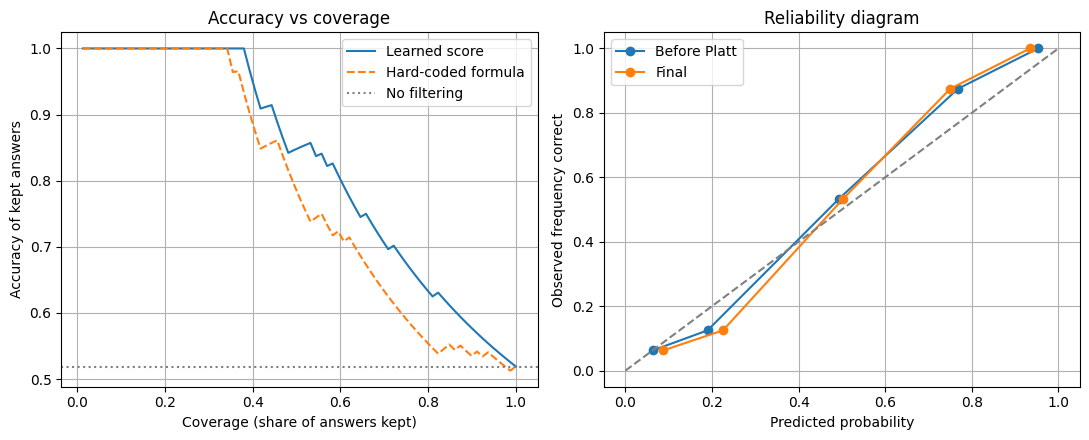

In [29]:
# ============================================================
# 11. PLATT CALIBRATION + CONTRADICTION GATE + FINAL EVALUATION
# ============================================================
if not CAN_MODEL:
    raise StopCell("Not enough labelled data yet - see the message in cell 8.")

from IPython.display import display
from scipy.special import expit
from sklearn.calibration import calibration_curve

# --- Calibration is fitted on OUT-OF-FOLD scores of the TRAIN set, so the test set stays untouched
#     (the old version calibrated on the test set and then evaluated on it -> optimistic numbers). ---
z_oof = cross_val_predict(best_lr, X_train, y_train, cv=cv, method="decision_function")
platt = LogisticRegression(C=1e6, max_iter=1000).fit(z_oof.reshape(-1, 1), y_train)   # ~unregularised 1-D logistic
platt_slope, platt_intercept = float(platt.coef_[0, 0]), float(platt.intercept_[0])

def platt_apply(z):
    return expit(platt_slope * np.asarray(z) + platt_intercept)

# --- Hard gate: cap the score when NLI is confident the answer contradicts the evidence.
#     Threshold chosen on out-of-fold train predictions; adopted only if it clearly helps. ---
ci = FEATURES.index("p_contradiction_max")
p_oof = platt_apply(z_oof)
auc_no_gate = roc_auc_score(y_train, p_oof)
gate_threshold, best_gate_auc = None, auc_no_gate + GATE_MIN_GAIN
for t in np.linspace(0.1, 0.9, 9):
    gated = np.where(X_train[:, ci] > t, np.minimum(p_oof, GATE_CAP), p_oof)
    a = roc_auc_score(y_train, gated)
    if a > best_gate_auc:
        gate_threshold, best_gate_auc = float(t), a
print(f"Out-of-fold AUC without gate: {auc_no_gate:.3f}")
print("Gate adopted at p_contradiction_max >", gate_threshold, f"(AUC {best_gate_auc:.3f})" if gate_threshold is not None
      else "-> NOT adopted (it did not improve cross-validated AUC enough)")

def apply_gate(p, X_):
    if gate_threshold is None:
        return p
    return np.where(X_[:, ci] > gate_threshold, np.minimum(p, GATE_CAP), p)

# --- Final scores on the untouched test set ---
z_test = best_lr.decision_function(X_test)
p_test_calibrated = platt_apply(z_test)
final_scores = apply_gate(p_test_calibrated, X_test)

# --- Metrics with bootstrap 95% CIs ---
rng = np.random.default_rng(SEED)

def boot_ci(metric, y_true, s, n_iter=1000):
    vals, n = [], len(y_true)
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric(y_true[idx], s[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(lo), float(hi)

def expected_calibration_error(y_true, p, n_bins=10):
    bin_id = np.minimum((np.asarray(p) * n_bins).astype(int), n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        m = bin_id == b
        if m.any():
            ece += m.mean() * abs(y_true[m].mean() - np.asarray(p)[m].mean())
    return float(ece)

def summarize(name, s, is_probability=True):
    lo, hi = boot_ci(roc_auc_score, y_test, s)
    row = {"model": name, "AUC": roc_auc_score(y_test, s), "AUC 95% CI": f"[{lo:.2f}, {hi:.2f}]",
           "PR-AUC": average_precision_score(y_test, s), "Brier": np.nan, "ECE": np.nan}
    if is_probability:
        row["Brier"] = brier_score_loss(y_test, s)
        row["ECE"] = expected_calibration_error(y_test, s)
    return row

table = pd.DataFrame([
    summarize("Hard-coded formula (current)", baseline_test, is_probability=False),
    summarize(f"Best single feature ({best_single})", single_scores[best_single], is_probability=False),
    summarize("Logistic regression (uncalibrated)", lr_test_probs),
    summarize("Shallow GBM (comparison)", gbm_test_probs),
    summarize("FINAL: logistic + Platt" + (" + gate" if gate_threshold is not None else ""), final_scores),
])
print("\n--- TEST-SET COMPARISON (Brier/ECE only make sense for real probabilities) ---")
display(table.round(3))

# --- Accuracy vs coverage: "if we only trust answers scoring above X, how accurate are they?" ---
def acc_vs_cov(y_true, s):
    order = np.argsort(-np.asarray(s), kind="stable")
    ys = y_true[order]
    k = np.arange(1, len(ys) + 1)
    return k / len(ys), np.cumsum(ys) / k

cov_f, acc_f = acc_vs_cov(y_test, final_scores)
cov_b, acc_b = acc_vs_cov(y_test, baseline_test)
half = int(np.ceil(0.5 * len(y_test))) - 1
acc_at_50 = float(acc_f[half])
print(f"\nRaw LLM accuracy: {y_test.mean():.1%} | keeping the top 50% by FINAL score: {acc_at_50:.1%} "
      f"| top 50% by hard-coded formula: {float(acc_b[half]):.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(cov_f, acc_f, label="Learned score"); ax[0].plot(cov_b, acc_b, label="Hard-coded formula", linestyle="--")
ax[0].axhline(y_test.mean(), color="gray", linestyle=":", label="No filtering")
ax[0].set_xlabel("Coverage (share of answers kept)"); ax[0].set_ylabel("Accuracy of kept answers")
ax[0].set_title("Accuracy vs coverage"); ax[0].grid(True); ax[0].legend()

n_bins = 5
pt_raw, pp_raw = calibration_curve(y_test, lr_test_probs, n_bins=n_bins, strategy="quantile")
pt_fin, pp_fin = calibration_curve(y_test, final_scores, n_bins=n_bins, strategy="quantile")
ax[1].plot(pp_raw, pt_raw, marker="o", label="Before Platt")
ax[1].plot(pp_fin, pt_fin, marker="o", label="Final")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("Predicted probability"); ax[1].set_ylabel("Observed frequency correct")
ax[1].set_title("Reliability diagram"); ax[1].grid(True); ax[1].legend()
plt.tight_layout(); plt.show()
